# Pruebas del modelo de SI

Pruebas para ver qué tanto se puede mejorar la predicción del Índice de Severidad (SI) por colonia y banda horaria:

1. **Ubicación**: ¿agregar latitud/longitud de la colonia mejora el modelo?
2. **ALPHA**: ¿cómo cambia la capacidad de predecir el SI según el peso de la violencia vs el robo?
3. **Clasificación**: ¿el modelo acierta si la colonia es de riesgo bajo, medio o alto?
4. **Diagnóstico**: ¿en qué colonias falla y por qué?

Todas las pruebas usan una fila por colonia × banda horaria (sin filtrar por SI) y validación cruzada **por colonia** (`GroupKFold`): cada colonia se evalúa con un modelo que nunca la vio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

AZUL, NARANJA = "#2a78d6", "#eb6834"
TINTA, TINTA_2, FONDO, REJILLA = "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"

delitos = pd.read_csv("Crime_Population.csv", encoding="utf-8")
delitos_violentos = ["Violencia familiar", "Lesiones dolosas", "Abuso sexual infantil",
                     "Homicidio doloso", "Violacion", "Feminicidio"]

delitos_patrimonio = [d for d in delitos["delito"].unique() if d.startswith("Robo")]

bandas = ["madrugada", "manana", "mediodia", "tarde", "noche"]

delitos["banda_horaria"] = pd.cut(delitos["hora"], bins=[0, 5, 10, 15, 20, 24], labels=bandas,
                                  right=False).astype("object")

delitos["n_violence"] = delitos["delito"].isin(delitos_violentos).astype(int)
delitos["n_property"] = delitos["delito"].isin(delitos_patrimonio).astype(int)

llave = ["colonia", "municipio"]

features_censo = ["poblacion_colonia", "Grado promedio de escolaridad", "tasa_desempleo",
                  "prop_sin_salud", "prop_sin_vehiculo", "prop_internet", "prop_18_24",
                  "relacion_hombres_mujeres", "prop_jefatura_femenina",
                  "prop_viviendas_deshabitadas", "prop_nacidos_otra_entidad",
                  "densidad_hab_km2", "ocupantes_por_cuarto"]

colonias = delitos.groupby(llave)[features_censo].first().dropna()

# con menos de 1000 habitantes un par de delitos dispara la tasa
colonias = colonias[colonias["poblacion_colonia"] >= 1000]

# Crime_Population.csv no trae coordenadas: se toman del archivo original. Mediana de los
# puntos de cada colonia, robusta a delitos mal geocodificados
crudo = pd.read_csv("datos-2026-09-09.csv", encoding="utf-8-sig",
                    usecols=["colonia", "municipio", "x", "y"])
ubicacion = crudo.groupby(llave)[["x", "y"]].median().rename(columns={"x": "longitud", "y": "latitud"})
colonias = colonias.join(ubicacion, how="inner")

conteos = delitos.dropna(subset=["banda_horaria"]).groupby(llave + ["banda_horaria"])[
    ["n_violence", "n_property"]].sum()
malla = pd.MultiIndex.from_tuples([(c, m, b) for c, m in colonias.index for b in bandas],
                                  names=llave + ["banda_horaria"])
# una fila por colonia x banda; las bandas sin delitos entran con conteo 0
base = conteos.reindex(malla, fill_value=0).reset_index().merge(colonias.reset_index(), on=llave)
grupos = base["colonia"] + "|" + base["municipio"]
cv = GroupKFold(n_splits=5)
print(f"{len(colonias)} colonias x {len(bandas)} bandas = {len(base)} filas")

1033 colonias x 5 bandas = 5165 filas


In [2]:
def calcular_si(alpha, percentil=0.99):
    """SI de cada fila de `base`, con la misma escala que Crime_Population2: el tope y el
    minimo se toman sobre los delitos, no sobre la malla colonia x banda."""
    cnt = delitos.groupby(llave + ["banda_horaria"])[["n_violence", "n_property"]].transform("sum")
    x_fila = (alpha * cnt["n_violence"] + (1 - alpha) * cnt["n_property"]) / delitos["poblacion_colonia"]
    tope, piso = x_fila.quantile(percentil), x_fila.min()
    x = (alpha * base["n_violence"] + (1 - alpha) * base["n_property"]) / base["poblacion_colonia"]
    return (100 * (x.clip(upper=tope) - piso) / (tope - piso)).clip(lower=0)


def matriz(columnas):
    X = pd.get_dummies(base[columnas + ["banda_horaria"]], columns=["banda_horaria"], dtype=int)
    for col in ("poblacion_colonia", "densidad_hab_km2"):
        if col in X:
            X[col] = np.log(X[col])   # van de cientos a decenas de miles
    return X


def lineal():
    return make_pipeline(StandardScaler(), LinearRegression())


def bosque():
    # hojas grandes y la mitad de variables por corte: con hojas chicas sobreajusta
    return RandomForestRegressor(n_estimators=300, min_samples_leaf=20, max_features=0.5,
                                 n_jobs=-1, random_state=0)


def evaluar(modelo, X, y):
    pred = cross_val_predict(modelo, X, y, groups=grupos, cv=cv)
    return pred, r2_score(y, pred), mean_absolute_error(y, pred)


def estilo(ax):
    ax.set_facecolor(FONDO)
    ax.grid(color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TINTA_2)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color("#c9c8c3")


y = calcular_si(0.99)
print(f"SI (ALPHA=0.99): media {y.mean():.1f}, mediana {y.median():.1f}, max {y.max():.0f}")

SI (ALPHA=0.99): media 13.0, mediana 11.0, max 100


## 1. ¿Agregar la ubicación mejora el modelo?

El crimen se concentra en el espacio: colonias vecinas se parecen. Se compara el modelo solo con censo, censo + latitud/longitud, y solo ubicación.

Nota: la validación separa colonias, pero las **vecinas** de una colonia de prueba sí pueden estar en entrenamiento. Eso es legítimo si el uso es "estimar el riesgo de una colonia conociendo el de su zona"; no lo sería para predecir una ciudad nueva.

In [3]:
conjuntos = {
    "Solo censo":        features_censo,
    "Censo + ubicacion": features_censo + ["latitud", "longitud"],
    "Solo ubicacion":    ["latitud", "longitud"],
}
filas, predicciones = [], {}
_, r2, mae = evaluar(DummyRegressor(), matriz(features_censo), y)
filas.append({"Variables": "(promedio, baseline)", "Modelo": "-", "R2": r2, "MAE": mae})
for nombre, columnas in conjuntos.items():
    X = matriz(columnas)
    for nombre_modelo, fabrica in (("Lineal", lineal), ("Random Forest", bosque)):
        pred, r2, mae = evaluar(fabrica(), X, y)
        predicciones[(nombre, nombre_modelo)] = pred
        filas.append({"Variables": nombre, "Modelo": nombre_modelo, "R2": r2, "MAE": mae})

tabla_ubicacion = pd.DataFrame(filas).round(3)
tabla_ubicacion

,Variables,Modelo,R2,MAE
0,"(promedio, baseline)",-,-0.001,7.777
1,Solo censo,Lineal,0.311,5.847
2,Solo censo,Random Forest,0.303,5.771
3,Censo + ubicacion,Lineal,0.308,5.859
4,Censo + ubicacion,Random Forest,0.311,5.736
5,Solo ubicacion,Lineal,0.201,6.475
6,Solo ubicacion,Random Forest,0.289,6.004


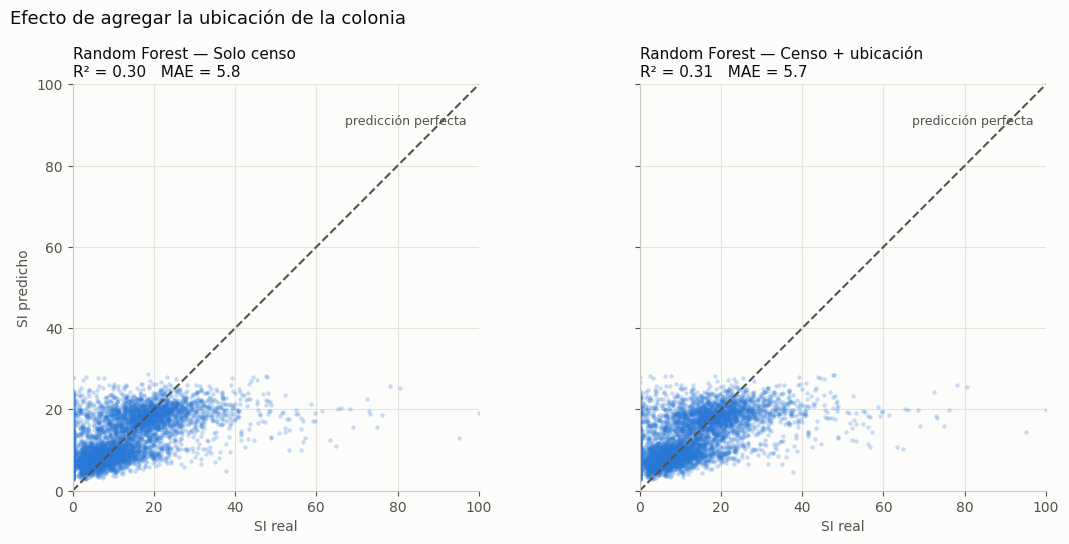

In [4]:
# SI predicho vs real: el mejor modelo sin y con ubicacion
comparar = [("Solo censo", "Random Forest"), ("Censo + ubicacion", "Random Forest")]
limite = 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, facecolor=FONDO)
for ax, clave in zip(axes, comparar):
    pred = predicciones[clave]
    estilo(ax)
    ax.scatter(y, pred, s=10, alpha=0.25, color=AZUL, linewidths=0)
    ax.plot([0, limite], [0, limite], color=TINTA_2, linewidth=1.5, linestyle="--")
    ax.text(limite * 0.97, limite * 0.90, "predicción perfecta", color=TINTA_2, ha="right", fontsize=9)
    ax.set_title(f"{clave[1]} — {clave[0].replace('ubicacion', 'ubicación')}\n"
                 f"R² = {r2_score(y, pred):.2f}   MAE = {mean_absolute_error(y, pred):.1f}",
                 color=TINTA, fontsize=11, loc="left")
    ax.set_xlabel("SI real", color=TINTA_2)
    ax.set_xlim(0, limite)
    ax.set_ylim(0, limite)
    ax.set_aspect("equal")
axes[0].set_ylabel("SI predicho", color=TINTA_2)
fig.suptitle("Efecto de agregar la ubicación de la colonia", color=TINTA, fontsize=13, x=0.06, ha="left")
fig.tight_layout()
plt.show()

## 2. ¿Cómo cambia la predicción según ALPHA?

Con `ALPHA = 0.99` el SI es casi solo violencia. Se recalcula el SI con otros pesos y se mide qué tanto lo explica el mismo modelo (Random Forest, censo + ubicación). Un R² distinto significa que ese SI es más o menos predecible, no que un ALPHA sea "correcto".

In [5]:
X_completo = matriz(features_censo + ["latitud", "longitud"])
filas = []
for alpha in (0.99, 0.9, 0.7, 0.5, 0.3):
    y_alpha = calcular_si(alpha)
    _, r2, mae = evaluar(bosque(), X_completo, y_alpha)
    filas.append({"ALPHA": alpha, "peso del robo": f"{1 - alpha:.0%}",
                  "SI mediana": y_alpha.median(), "R2": r2, "MAE": mae,
                  "corr. con SI 0.99": np.corrcoef(y_alpha, y)[0, 1]})
pd.DataFrame(filas).round(3)

,ALPHA,peso del robo,SI mediana,R2,MAE,corr. con SI 0.99
0,0.99,1%,10.963,0.311,5.736,1.000
1,0.90,10%,8.536,0.261,4.460,0.954
2,0.70,30%,5.425,0.226,3.193,0.741
3,0.50,50%,3.547,0.236,2.548,0.583
4,0.30,70%,2.582,0.247,2.300,0.485


## 3. Clasificación: riesgo bajo, medio o alto

En lugar de predecir el número exacto, se divide el SI en terciles y se mide si el modelo pone cada colonia × banda en la categoría correcta. La exactitud balanceada de adivinar al azar es 0.33.

In [6]:
niveles = ["bajo", "medio", "alto"]
clase = pd.qcut(y, 3, labels=niveles)
print("Cortes de SI:", [round(v, 1) for v in pd.qcut(y, 3, retbins=True)[1]])

clasificadores = {
    "Clase mas frecuente (baseline)": (DummyClassifier(strategy="most_frequent"), matriz(features_censo)),
    "Random Forest - solo censo": (None, matriz(features_censo)),
    "Random Forest - censo + ubicacion": (None, X_completo),
}
filas, pred_clase = [], {}
for nombre, (modelo, X) in clasificadores.items():
    modelo = modelo or RandomForestClassifier(n_estimators=300, min_samples_leaf=20, max_features=0.5,
                                              n_jobs=-1, random_state=0)
    pred = cross_val_predict(modelo, X, clase, groups=grupos, cv=cv)
    pred_clase[nombre] = pred
    alto = clase == "alto"
    filas.append({"Modelo": nombre,
                  "Exactitud balanceada": balanced_accuracy_score(clase, pred),
                  "Altos detectados": (pred[alto] == "alto").mean(),
                  "Altos confundidos con bajo": (pred[alto] == "bajo").mean()})
pd.DataFrame(filas).round(3)

Cortes de SI: [np.float64(0.0), np.float64(7.5), np.float64(15.7), np.float64(100.0)]


,Modelo,Exactitud balanceada,Altos detectados,Altos confundidos con bajo
0,Clase mas frecuente (baseline),0.319,0.386,0.204
1,Random Forest - solo censo,0.596,0.789,0.082
2,Random Forest - censo + ubicacion,0.599,0.794,0.083


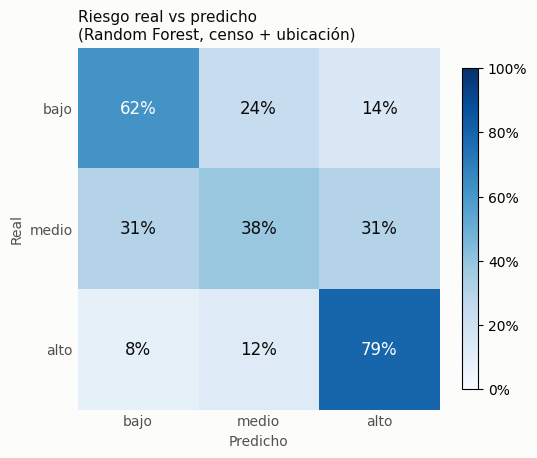

In [7]:
# matriz de confusion del mejor clasificador, normalizada por fila (lo real)
pred = pred_clase["Random Forest - censo + ubicacion"]
cm = confusion_matrix(clase, pred, labels=niveles, normalize="true")

fig, ax = plt.subplots(figsize=(5.5, 4.8), facecolor=FONDO)
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i, j]:.0%}", ha="center", va="center", fontsize=12,
                color="white" if cm[i, j] > 0.5 else TINTA)
ax.set_xticks(range(3), niveles)
ax.set_yticks(range(3), niveles)
ax.set_xlabel("Predicho", color=TINTA_2)
ax.set_ylabel("Real", color=TINTA_2)
ax.tick_params(colors=TINTA_2, length=0)
for lado in ax.spines.values():
    lado.set_visible(False)
ax.set_title("Riesgo real vs predicho\n(Random Forest, censo + ubicación)", color=TINTA,
             fontsize=11, loc="left")
fig.colorbar(im, ax=ax, format=lambda v, _: f"{v:.0%}", shrink=0.8)
fig.tight_layout()
plt.show()

## 4. ¿En qué colonias falla el modelo?

Hipótesis: las colonias que el modelo subestima son zonas comerciales o de paso, donde viven pocas personas pero transitan muchas. Ahí la tasa por residente se infla y el censo (que describe a los residentes) no lo puede anticipar.

In [8]:
pred = predicciones[("Censo + ubicacion", "Random Forest")]
error = base[llave].assign(SI_real=y, SI_predicho=pred)
por_colonia = error.groupby(llave)[["SI_real", "SI_predicho"]].mean()
por_colonia["subestimado"] = por_colonia["SI_real"] - por_colonia["SI_predicho"]
por_colonia = por_colonia.join(colonias[["poblacion_colonia", "densidad_hab_km2",
                                         "prop_viviendas_deshabitadas"]])

peores = por_colonia.nlargest(15, "subestimado")
print("Mediana de todas las colonias:")
print(por_colonia[["poblacion_colonia", "densidad_hab_km2", "prop_viviendas_deshabitadas"]]
      .median().round(3).to_string())
peores.round(3)

Mediana de todas las colonias:
poblacion_colonia              3065.000
densidad_hab_km2               9997.029
prop_viviendas_deshabitadas       0.091


,,SI_real,SI_predicho,subestimado,poblacion_colonia,densidad_hab_km2,prop_viviendas_deshabitadas
colonia,municipio,,,,,,
ZONA CENTRO,GUADALAJARA,60.452,15.927,44.525,13033.0,4150.465,0.185
HACIENDA LOS FRESNOS,TLAJOMULCO DE ZUÑIGA,53.285,14.226,39.059,2806.0,10248.331,0.245
ARCOS VALLARTA,GUADALAJARA,50.550,12.362,38.188,1669.0,1815.903,0.169
CENTRO,EL SALTO,52.677,15.711,36.966,8627.0,5067.079,0.171
PLAN DE ORIENTE,SAN PEDRO TLAQUEPAQUE,54.966,20.171,34.795,1485.0,4956.058,0.110
CONCEPCION DEL VALLE (LA CONCHA),TLAJOMULCO DE ZUÑIGA,50.747,16.485,34.262,1158.0,3945.194,0.139
AMERICANA,GUADALAJARA,48.488,15.349,33.140,3885.0,2708.416,0.170
LA AZUCENA,EL SALTO,44.838,12.437,32.402,2327.0,18226.845,0.229
EL FORTIN,ZAPOPAN,38.393,9.042,29.351,2257.0,5032.027,0.160


In [9]:
# comparacion: las 50 colonias mas subestimadas vs el resto
top = por_colonia["subestimado"].rank(ascending=False) <= 50
comparacion = por_colonia.groupby(top.map({True: "50 más subestimadas", False: "resto"}))[
    ["poblacion_colonia", "densidad_hab_km2", "prop_viviendas_deshabitadas", "SI_real"]].median()
comparacion.round(3)

,poblacion_colonia,densidad_hab_km2,prop_viviendas_deshabitadas,SI_real
subestimado,,,,
50 más subestimadas,1982.5,5075.086,0.134,30.793
resto,3147.0,10286.224,0.089,12.407


## Conclusiones

**1. La ubicación no mejora el modelo** (R² 0.30 → 0.31). Pero la ubicación *sola* logra 0.29: la latitud/longitud y el censo cargan casi la misma información. En la ZMG, dónde está la colonia y su nivel socioeconómico van de la mano.

**2. El SI con ALPHA = 0.99 es el más predecible** (R² 0.31). Al darle más peso al robo, el R² baja a ~0.23–0.25: el censo explica mejor la violencia que el robo, porque el robo depende de dónde está la actividad comercial, no de quién vive ahí.

**3. Como clasificación el modelo sí es útil.** Exactitud balanceada de 0.60 contra 0.32 de adivinar. Detecta el **79% de las colonias × banda de riesgo alto**, y solo el 8% de las altas las confunde con bajas. La clase "medio" es la difícil (38%), lo esperable en la categoría intermedia.

**4. Las fallas confirman la hipótesis de la población flotante.** Las colonias más subestimadas son zonas centrales, comerciales o industriales: Zona Centro, Americana, Arcos Vallarta, Moderna, Centro de El Salto, Álamo Industrial. Comparadas con el resto tienen la mitad de densidad (5,075 vs 10,286 hab/km²), menos residentes y más viviendas deshabitadas (13% vs 9%). Ahí la tasa por residente se infla con delitos contra gente que no vive en la colonia, y el censo no lo puede anticipar.

**Recomendación:** presentar el modelo como **clasificador de riesgo** (bajo / medio / alto), que es donde rinde bien, y documentar como limitación que en zonas comerciales la tasa por residente sobreestima el riesgo.